In [303]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import ast
from sklearn.metrics import accuracy_score
import copy
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score,average_precision_score)
from sklearn.neural_network import MLPClassifier

In [304]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

In [305]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
from scipy.stats import spearmanr
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

# Load

In [306]:
newness = np.load("D:\\MissTiny\\GitHub\\Creativity_Artnet\\Datasets\\newness_2024.npy",allow_pickle=True)
surprise = np.load("D:\\MissTiny\\GitHub\\Creativity_Artnet\\Datasets\\surprise_2024.npy",allow_pickle=True)
value = np.load("D:\\MissTiny\\GitHub\\Creativity_Artnet\\Datasets\\value_2024.npy",allow_pickle=True)

In [307]:
BASELINE_YEAR=1600

In [308]:
gold_set_70 = pd.read_excel("D:\\MissTiny\\GitHub\\Creativity_Artnet\\Codes\\Evaluation\\golden_set_move_creative_70.xlsx")

In [309]:
creative_70 = np.load("D:\\MissTiny\\GitHub\\Creativity_Artnet\\Datasets\\creativity_70_full_prob.npy",allow_pickle=True)

In [310]:
artnet_2024 = pd.read_excel("D:\\MissTiny\\GitHub\\Creativity_Artnet\\Datasets\\ArtNet\\Artnet_Europe_2024_merged.xlsx")

In [311]:
merged_df = pd.merge(gold_set_70, artnet_2024[["artwork id","artist id","year born","workyear modifier","price","artist",'est lo usd','est hi usd', 'sale price usd']], on='artwork id', how='left')

In [312]:
merged_df.shape

(1874, 33)

In [313]:
newness_df = np.zeros(merged_df.shape[0], dtype=object)
surprise_df = np.zeros(merged_df.shape[0], dtype=object)
value_df = np.zeros(merged_df.shape[0], dtype=object)
for i in range(merged_df.shape[0]):
    row_index = merged_df.index[i]
    newness_df[i] =newness[row_index]
    surprise_df[i] =surprise[row_index]
    value_df[i] = value[row_index]

# Correlation

In [314]:
new_vs_surprise, pval = spearmanr(newness,surprise)
print(f"The Correlation between newness and Surprise is {new_vs_surprise}")

The Correlation between newness and Surprise is 0.2985509641365827


In [315]:
new_vs_value, pval = spearmanr(newness,value)
print(f"The Correlation between newness and value is {new_vs_value}")

The Correlation between newness and value is 0.042086096035055594


In [316]:
value_vs_surprise, pval = spearmanr(value,surprise)
print(f"The Correlation between surprise and value is {value_vs_surprise}")

The Correlation between surprise and value is 0.030809796371711884


# Cut off 0.85

## Basic
Balanced + Normalized (max min)

In [317]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [318]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [319]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [320]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [321]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.99027119484493.


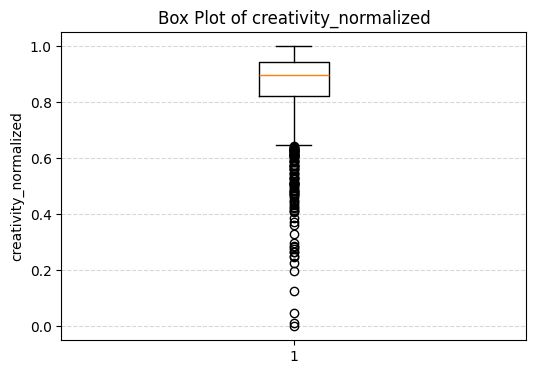

In [322]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [323]:
percentile = (creativity_normalized <= 0.85).mean() * 100
percentile

np.float64(32.17716115261473)

In [324]:
y = [1 if i>=0.85 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [325]:
np.sum(y)/len(y)

np.float64(0.6782283884738527)

In [326]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [327]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`

In [328]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 47.73%
Test AUC: 0.4608251447907854
Test Precision: 0.6542553191489362
Test Recall: 0.484251968503937
Test F1: 0.5565610859728507


In [329]:
confusion_matrix(y_test, model.predict(X_test))

array([[ 56,  65],
       [131, 123]])

## Splines 
Splines + Balanced + Normalized (max min)

In [330]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [331]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.99027119484493.


In [332]:
y = [1 if i>=0.85 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [333]:
np.sum(y)/len(y)

np.float64(0.6782283884738527)

In [334]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [335]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [336]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [337]:
model.fit(X_train, y_train)

C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregressioncv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('spline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [338]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [339]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 53.60%
Test AUC: 0.4936226979891976
Test Precision: 0.6709401709401709
Test Recall: 0.6181102362204725
Test F1: 0.6434426229508197


In [340]:
confusion_matrix(y_test, y_pred)

array([[ 44,  77],
       [ 97, 157]])

## Neural Network

In [341]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [342]:
constant = np.ones(len(surprise_df))

In [343]:
y = [1 if i>=0.85 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [344]:
np.sum(y)/len(y)

np.float64(0.6782283884738527)

In [345]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [346]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [347]:
result=[]
best_alpha=None
best_layer=None
best_score=None
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.20, random_state=23,stratify=y_train)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train1)
        
        model.fit(X_train1, y_train1, sample_weight = sample_weights)

        
            
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:,1]
        acc = accuracy_score(y_val,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_val, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_val,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_val, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_val, y_pred)

        if best_alpha==None:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
        elif best_score > auc:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
            
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_val, y_pred)})
        #print("Test F1:", f1)

In [350]:
model = MLPClassifier(solver='lbfgs', alpha=best_alpha,
                    hidden_layer_sizes=best_layer, random_state=1,max_iter=5000)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model.fit(X_train, y_train, sample_weight = sample_weights)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob)
print("Test AUC:", auc)
precision = precision_score(y_test,y_pred)
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 52.80%
Test AUC: 0.5335459100670268
Test Precision: 0.7015706806282722
Test Recall: 0.5275590551181102
Test F1: 0.6022471910112359


In [351]:
confusion_matrix(y_test, y_pred)

array([[ 64,  57],
       [120, 134]])

# Cut off 0.80

## Basic
Balanced + Normalized (max min)

In [368]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [369]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [370]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [371]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [372]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.99027119484493.


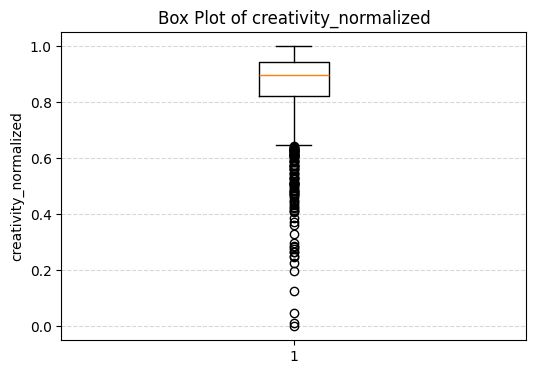

In [373]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [374]:
y = [1 if i>=0.8 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [375]:
np.sum(y)/len(y)

np.float64(0.7913553895410885)

In [376]:
percentile = (creativity_normalized <= 0.8).mean() * 100
percentile

np.float64(20.86446104589114)

In [377]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [378]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`

In [379]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 43.73%
Test AUC: 0.502417335750669
Test Precision: 0.7866666666666666
Test Recall: 0.39730639730639733
Test F1: 0.5279642058165548


In [380]:
confusion_matrix(y_test, model.predict(X_test))

array([[ 46,  32],
       [179, 118]])

## Splines 
Splines + Balanced + Normalized (max min)

In [381]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [382]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.99027119484493.


In [383]:
y = [1 if i>=0.8 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [384]:
np.sum(y)/len(y)

np.float64(0.7913553895410885)

In [417]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [418]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [419]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [420]:
model.fit(X_train, y_train)

C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregressioncv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('spline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [421]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [422]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 54.13%
Test AUC: 0.4966329966329966
Test Precision: 0.7880184331797235
Test Recall: 0.5757575757575758
Test F1: 0.6653696498054474


In [423]:
confusion_matrix(y_test, y_pred)

array([[ 32,  46],
       [126, 171]])

## Neural Network

In [424]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [425]:
constant = np.ones(len(surprise_df))

In [426]:
y = [1 if i>=0.8 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [427]:
np.sum(y)/len(y)

np.float64(0.7913553895410885)

In [428]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [429]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [430]:
result=[]
best_alpha=None
best_layer=None
best_score=None
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.20, random_state=23,stratify=y_train)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train1)
        
        model.fit(X_train1, y_train1, sample_weight = sample_weights)

        
            
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:,1]
        acc = accuracy_score(y_val,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_val, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_val,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_val, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_val, y_pred)

        if best_alpha==None:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
        elif best_score > auc:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
            
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_val, y_pred)})
        #print("Test F1:", f1)

In [431]:
model = MLPClassifier(solver='lbfgs', alpha=best_alpha,
                    hidden_layer_sizes=best_layer, random_state=1,max_iter=5000)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model.fit(X_train, y_train, sample_weight = sample_weights)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob)
print("Test AUC:", auc)
precision = precision_score(y_test,y_pred)
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)
confusion_matrix(y_test, y_pred)

Test Logistic Regression model accuracy: 50.13%
Test AUC: 0.48877665544332216
Test Precision: 0.7956989247311828
Test Recall: 0.4983164983164983
Test F1: 0.6128364389233955


In [433]:
confusion_matrix(y_test, y_pred)

array([[ 40,  38],
       [149, 148]])

In [432]:
df = pd.DataFrame(result)
df

,alpha,layer,acc,auc,precision,recall,f1,conf_matrix
0,0.000001,"(4, 4)",53.666667,0.528531,0.810127,0.540084,0.648101,"[[33, 30], [109, 128]]"
1,0.000001,"(4, 8)",44.000000,0.530239,0.810811,0.379747,0.517241,"[[42, 21], [147, 90]]"
2,0.000001,"(8, 8)",37.333333,0.535195,0.795181,0.278481,0.412500,"[[46, 17], [171, 66]]"
3,0.000001,"(8, 16)",37.000000,0.553278,0.807692,0.265823,0.400000,"[[48, 15], [174, 63]]"
4,0.000001,"(16, 16)",53.000000,0.542295,0.811688,0.527426,0.639386,"[[34, 29], [112, 125]]"
5,0.000001,"(16, 32)",56.333333,0.500569,0.791209,0.607595,0.687351,"[[25, 38], [93, 144]]"
6,0.000003,"(4, 4)",48.333333,0.528732,0.801471,0.459916,0.584450,"[[36, 27], [128, 109]]"
7,0.000003,"(4, 8)",36.666667,0.479137,0.758242,0.291139,0.420732,"[[41, 22], [168, 69]]"
8,0.000003,"(8, 8)",37.333333,0.555823,0.810127,0.270042,0.405063,"[[48, 15], [173, 64]]"
9,0.000003,"(8, 16)",34.333333,0.505927,0.785714,0.232068,0.358306,"[[48, 15], [182, 55]]"


# Cut off 0.60

## Basic
Balanced + Normalized (max min)

In [434]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [435]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [436]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [437]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [438]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.99027119484493.


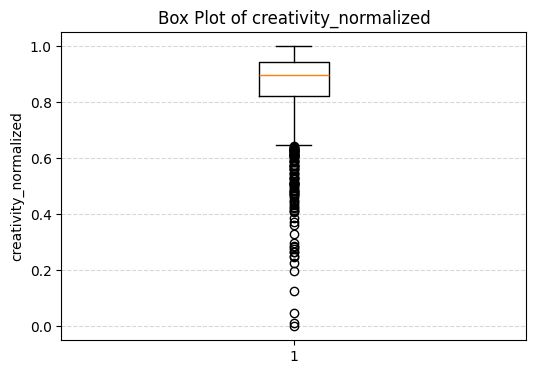

In [439]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [440]:
y = [1 if i>=0.6 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [441]:
np.sum(y)/len(y)

np.float64(0.9621131270010672)

In [443]:
percentile = (creativity_normalized <= 0.6).mean() * 100
percentile

np.float64(3.7886872998932764)

In [444]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [445]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`

In [446]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 54.67%
Test AUC: 0.5021764938662445
Test Precision: 0.9569377990430622
Test Recall: 0.554016620498615
Test F1: 0.7017543859649122


In [447]:
confusion_matrix(y_test, model.predict(X_test))

array([[  5,   9],
       [161, 200]])

## Splines 
Splines + Balanced + Normalized (max min)

In [459]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [460]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.99027119484493.


In [461]:
y = [1 if i>=0.6 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [462]:
np.sum(y)/len(y)

np.float64(0.9621131270010672)

In [463]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [464]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [465]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [466]:
model.fit(X_train, y_train)

C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregressioncv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('spline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [467]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [468]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 55.73%
Test AUC: 0.4800158290462999
Test Precision: 0.9620853080568721
Test Recall: 0.5623268698060941
Test F1: 0.7097902097902098


In [470]:
confusion_matrix(y_test, y_pred)

array([[  6,   8],
       [158, 203]])

## Neural Network

In [471]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [472]:
constant = np.ones(len(surprise_df))

In [473]:
y = [1 if i>=0.6 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [474]:
np.sum(y)/len(y)

np.float64(0.9621131270010672)

In [475]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [476]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [477]:
result=[]
best_alpha=None
best_layer=None
best_score=None
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.20, random_state=23,stratify=y_train)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train1)
        
        model.fit(X_train1, y_train1, sample_weight = sample_weights)

        
            
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:,1]
        acc = accuracy_score(y_val,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_val, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_val,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_val, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_val, y_pred)

        if best_alpha==None:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
        elif best_score > auc:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
            
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_val, y_pred)})
        #print("Test F1:", f1)

In [478]:
model = MLPClassifier(solver='lbfgs', alpha=best_alpha,
                    hidden_layer_sizes=best_layer, random_state=1,max_iter=5000)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model.fit(X_train, y_train, sample_weight = sample_weights)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob)
print("Test AUC:", auc)
precision = precision_score(y_test,y_pred)
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)
confusion_matrix(y_test, y_pred)

Test Logistic Regression model accuracy: 59.20%
Test AUC: 0.40799366838148005
Test Precision: 0.956140350877193
Test Recall: 0.6038781163434903
Test F1: 0.7402376910016978


array([[  4,  10],
       [143, 218]])

In [479]:
df = pd.DataFrame(result)
df

,alpha,layer,acc,auc,precision,recall,f1,conf_matrix
0,0.000001,"(4, 4)",54.000000,0.237811,0.941520,0.557093,0.700000,"[[1, 10], [128, 161]]"
1,0.000001,"(4, 8)",40.333333,0.474363,0.950820,0.401384,0.564477,"[[5, 6], [173, 116]]"
2,0.000001,"(8, 8)",54.333333,0.238754,0.941860,0.560554,0.702820,"[[1, 10], [127, 162]]"
3,0.000001,"(8, 16)",62.000000,0.297892,0.948718,0.640138,0.764463,"[[1, 10], [104, 185]]"
4,0.000001,"(16, 16)",59.666667,0.392891,0.956522,0.608997,0.744186,"[[3, 8], [113, 176]]"
5,0.000001,"(16, 32)",62.333333,0.531299,0.958333,0.636678,0.765073,"[[3, 8], [105, 184]]"
6,0.000003,"(4, 4)",56.000000,0.239698,0.943503,0.577855,0.716738,"[[1, 10], [122, 167]]"
7,0.000003,"(4, 8)",41.000000,0.516829,0.951613,0.408304,0.571429,"[[5, 6], [171, 118]]"
8,0.000003,"(8, 8)",54.333333,0.238754,0.941860,0.560554,0.702820,"[[1, 10], [127, 162]]"
9,0.000003,"(8, 16)",63.000000,0.270211,0.949495,0.650519,0.772074,"[[1, 10], [101, 188]]"


# Cut off 0.5

## Basic
Balanced + Normalized (max min)

In [480]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [481]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [482]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [483]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [484]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.99027119484493.


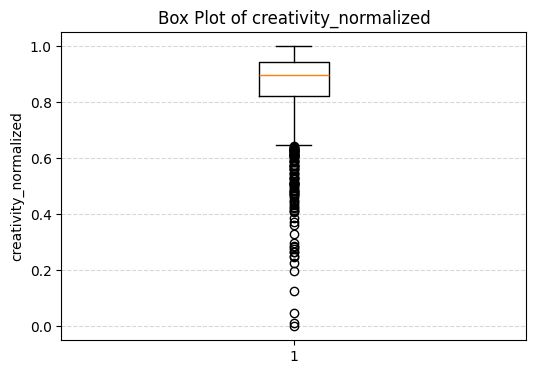

In [485]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [486]:
y = [1 if i>=0.5 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [487]:
percentile = (creativity_normalized <= 0.5).mean() * 100
percentile

np.float64(2.134471718249733)

In [488]:
np.sum(y)/len(y)

np.float64(0.9786552828175027)

In [494]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [495]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`

In [496]:
print(model.classes_)

[0 1]


In [501]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 56.53%
Test AUC: 0.3920299727520436
Test Precision: 0.9722222222222222
Test Recall: 0.5722070844686649
Test F1: 0.7204116638078902


In [499]:
confusion_matrix(y_test, model.predict(X_test))

array([[  2,   6],
       [157, 210]])

## Splines 
Splines + Balanced + Normalized (max min)

In [502]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [503]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.99027119484493.


In [504]:
y = [1 if i>=0.5 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [505]:
np.sum(y)/len(y)

np.float64(0.9786552828175027)

In [506]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [507]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [508]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [509]:
model.fit(X_train, y_train)

C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregressioncv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('spline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [510]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [511]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 48.80%
Test AUC: 0.3872615803814714
Test Precision: 0.972972972972973
Test Recall: 0.4904632152588556
Test F1: 0.6521739130434783


In [512]:
confusion_matrix(y_test, y_pred)

array([[  3,   5],
       [187, 180]])

## Neural Network

In [513]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [514]:
constant = np.ones(len(surprise_df))

In [515]:
y = [1 if i>=0.5 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [516]:
np.sum(y)/len(y)

np.float64(0.9786552828175027)

In [517]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [518]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [519]:
result=[]
best_alpha=None
best_layer=None
best_score=None
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.20, random_state=23,stratify=y_train)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train1)
        
        model.fit(X_train1, y_train1, sample_weight = sample_weights)

        
            
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:,1]
        acc = accuracy_score(y_val,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_val, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_val,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_val, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_val, y_pred)

        if best_alpha==None:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
        elif best_score > auc:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
            
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_val, y_pred)})
        #print("Test F1:", f1)



In [520]:
model = MLPClassifier(solver='lbfgs', alpha=best_alpha,
                    hidden_layer_sizes=best_layer, random_state=1,max_iter=5000)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model.fit(X_train, y_train, sample_weight = sample_weights)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob)
print("Test AUC:", auc)
precision = precision_score(y_test,y_pred)
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)
confusion_matrix(y_test, y_pred)

Test Logistic Regression model accuracy: 62.13%
Test AUC: 0.4982970027247956
Test Precision: 0.9828326180257511
Test Recall: 0.6239782016348774
Test F1: 0.7633333333333333


array([[  4,   4],
       [138, 229]])

In [145]:
df = pd.DataFrame(result)
df

,alpha,layer,acc,auc,precision,recall,f1,conf_matrix
0,0.000001,"(4, 4)",62.133333,0.498297,0.982833,0.623978,0.763333,"[[4, 4], [138, 229]]"
1,0.000001,"(4, 8)",45.866667,0.320163,0.965909,0.463215,0.626151,"[[2, 6], [197, 170]]"
2,0.000001,"(8, 8)",44.800000,0.421662,0.976190,0.446866,0.613084,"[[4, 4], [203, 164]]"
3,0.000001,"(8, 16)",48.533333,0.424728,0.972826,0.487738,0.649728,"[[3, 5], [188, 179]]"
4,0.000001,"(16, 16)",55.733333,0.398161,0.980861,0.558583,0.711806,"[[4, 4], [162, 205]]"
5,0.000001,"(16, 32)",59.466667,0.549046,0.986425,0.594005,0.741497,"[[5, 3], [149, 218]]"
6,0.000003,"(4, 4)",74.933333,0.326635,0.972318,0.765668,0.856707,"[[0, 8], [86, 281]]"
7,0.000003,"(4, 8)",42.133333,0.387772,0.974684,0.419619,0.586667,"[[4, 4], [213, 154]]"
8,0.000003,"(8, 8)",45.600000,0.440395,0.971098,0.457766,0.622222,"[[3, 5], [199, 168]]"
9,0.000003,"(8, 16)",44.533333,0.423365,0.976048,0.444142,0.610487,"[[4, 4], [204, 163]]"


# What if We renormalize the data

In [146]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [147]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.99027119484493.


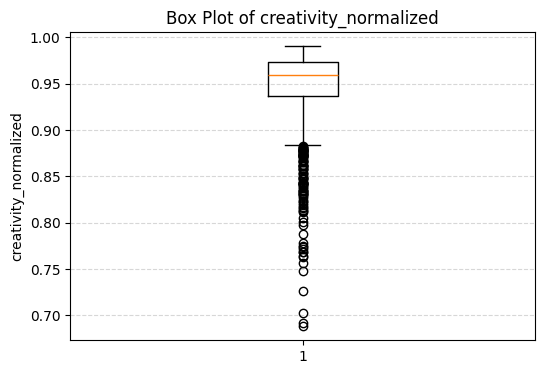

In [148]:
plt.figure(figsize=(6, 4))
plt.boxplot(creative_70, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [149]:
creative = np.array(creativity_normalized, dtype=float)
Q1 = np.percentile(creative, 25)
Q3 = np.percentile(creative, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
creative_outliers =creative[(creative < lower_bound) | (creative > upper_bound)]

In [150]:
np.max(creative_outliers)

np.float64(0.6433842697754195)

In [151]:
creative_new = creative[creative>=np.max(creative_outliers)]

In [152]:
creativity_min = np.min(creative_new)
creativity_max =np.max(creative_new)
creativity_normalized = (creative_new - creativity_min)/(creativity_max-creativity_min)

In [153]:
np.min(creativity_normalized)

np.float64(0.0)

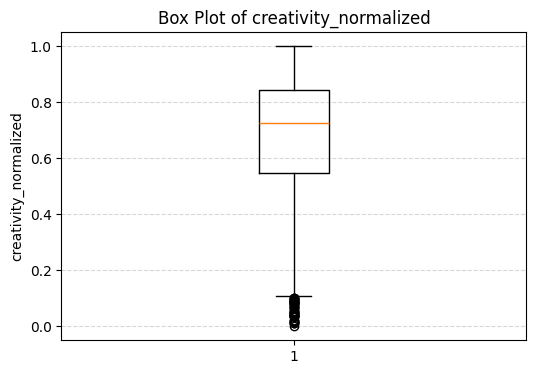

In [154]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [155]:
np.percentile(creativity_normalized, 50)

np.float64(0.7243554029776417)

## Cut off 0.7

### Basic
Balanced + Normalized (max min)

In [156]:
newness_df_new = newness_df[creative>=np.max(creative_outliers)]

In [157]:
newness_df_new.shape

(1775,)

In [158]:
newness_min=np.min(newness_df_new)
newness_max = np.max(newness_df_new)
newness_normalized=(newness_df_new - newness_min)/(newness_max-newness_min)

In [159]:
surprise_df_new = surprise_df[creative>=np.max(creative_outliers)]

In [160]:
surprise_df_new.shape

(1775,)

In [161]:
surprise_min=np.min(surprise_df_new)
surprise_max = np.max(surprise_df_new)
surprise_normalized=(surprise_df_new - surprise_min)/(surprise_max-surprise_min)

In [162]:
value_df_new = value_df[creative>=np.max(creative_outliers)]

In [163]:
value_df_new.shape

(1775,)

In [164]:
value_min=np.min(value_df_new)
value_max = np.max(value_df_new)
value_normalized=(value_df_new - value_min)/(value_max-value_min)

In [165]:
creativity_min = np.min(creative_new)
creativity_max =np.max(creative_new)
creativity_normalized = (creative_new - creativity_min)/(creativity_max-creativity_min)

In [166]:
creativity_normalized.shape

(1775,)

In [167]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6433842697754195. Creativity Max: 1.0.


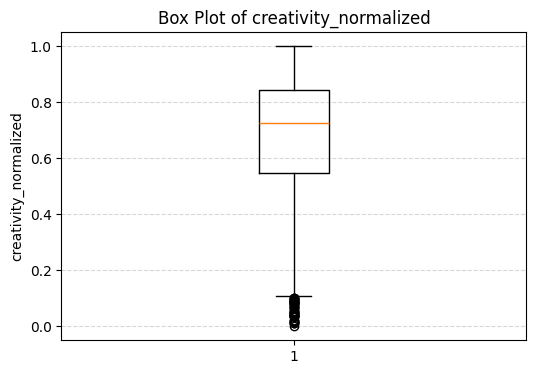

In [168]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [169]:
y = [1 if i>=0.7 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [170]:
np.sum(y)/len(y)

np.float64(0.5504225352112676)

In [171]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [172]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`

In [173]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 50.70%
Test AUC: 0.484102564102564
Test Precision: 0.553763440860215
Test Recall: 0.5282051282051282
Test F1: 0.5406824146981627


In [174]:
confusion_matrix(y_test, model.predict(X_test))

array([[ 77,  83],
       [ 92, 103]])

## Splines 
Splines + Balanced + Normalized (max min)

In [175]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [176]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.99027119484493.


In [177]:
y = [1 if i>=0.7 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [178]:
np.sum(y)/len(y)

np.float64(0.9071504802561366)

In [179]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [180]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [181]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [182]:
model.fit(X_train, y_train)

C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregressioncv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('spline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [183]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [184]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 52.53%
Test AUC: 0.3785714285714285
Test Precision: 0.875
Test Recall: 0.5558823529411765
Test F1: 0.6798561151079137


In [185]:
confusion_matrix(y_test, y_pred)

array([[  8,  27],
       [151, 189]])

## Neural Network

In [186]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [187]:
constant = np.ones(len(surprise_df))

In [188]:
y = [1 if i>=0.7 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [189]:
np.sum(y)/len(y)

np.float64(0.9071504802561366)

In [190]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [191]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [192]:
result=[]
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
        model.fit(X_train, y_train, sample_weight = sample_weights)
        y_pred = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:,1]
        acc = accuracy_score(y_test,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_test, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_test,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_test, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_test, y_pred)
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_test, y_pred)})
        #print("Test F1:", f1)


In [193]:
df = pd.DataFrame(result)
df

,alpha,layer,acc,auc,precision,recall,f1,conf_matrix
0,0.000001,"(4, 4)",58.933333,0.529412,0.918919,0.600000,0.725979,"[[17, 18], [136, 204]]"
1,0.000001,"(4, 8)",64.000000,0.475798,0.905138,0.673529,0.772344,"[[11, 24], [111, 229]]"
2,0.000001,"(8, 8)",53.600000,0.484538,0.919192,0.535294,0.676580,"[[19, 16], [158, 182]]"
3,0.000001,"(8, 16)",53.066667,0.518319,0.890476,0.550000,0.680000,"[[12, 23], [153, 187]]"
4,0.000001,"(16, 16)",55.466667,0.537899,0.898618,0.573529,0.700180,"[[13, 22], [145, 195]]"
5,0.000001,"(16, 32)",60.800000,0.493361,0.910638,0.629412,0.744348,"[[14, 21], [126, 214]]"
6,0.000003,"(4, 4)",58.933333,0.529412,0.918919,0.600000,0.725979,"[[17, 18], [136, 204]]"
7,0.000003,"(4, 8)",53.600000,0.483950,0.919192,0.535294,0.676580,"[[19, 16], [158, 182]]"
8,0.000003,"(8, 8)",53.600000,0.484538,0.919192,0.535294,0.676580,"[[19, 16], [158, 182]]"
9,0.000003,"(8, 16)",61.866667,0.502101,0.902041,0.650000,0.755556,"[[11, 24], [119, 221]]"
